✅ Dataset chargé et colonnes renommées.


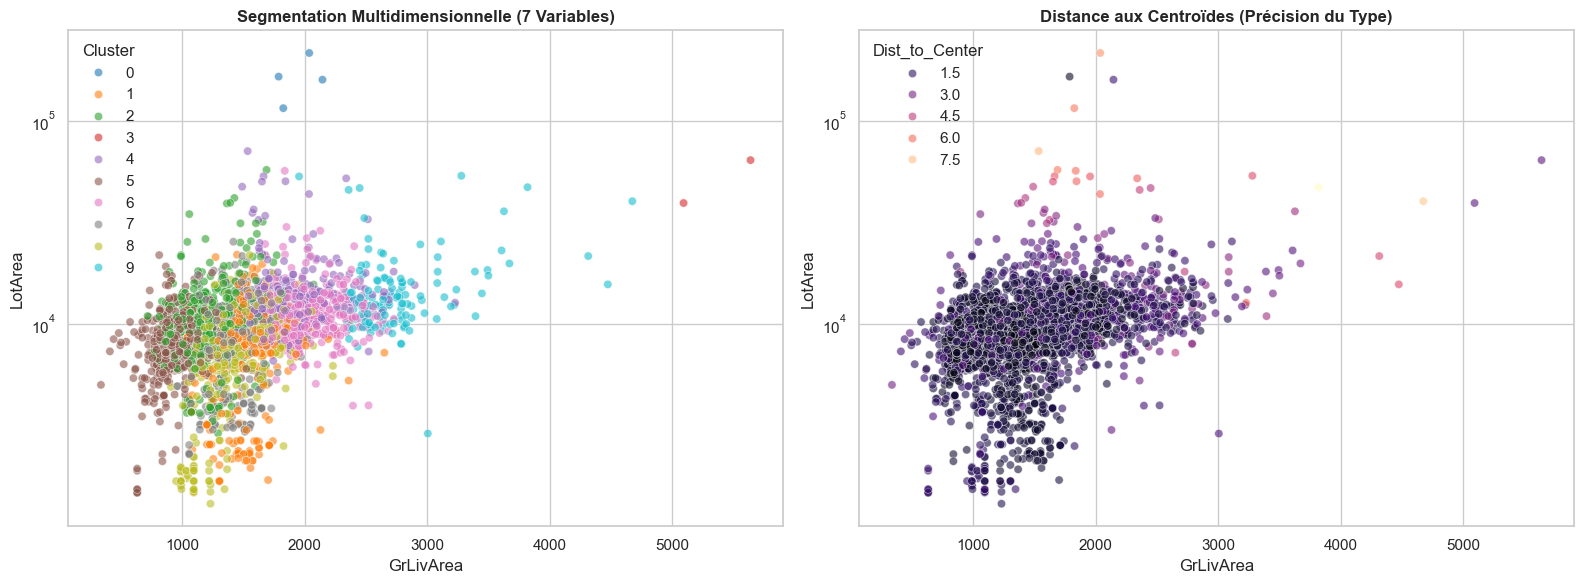

🚀 Succès : 10 colonnes de distance créées.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Configuration visuelle pour un rendu professionnel
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

# 1. CHARGEMENT ET NETTOYAGE DYNAMIQUE
try:
    df = pd.read_csv("ames.csv")
    # Correction des noms de colonnes (Kaggle -> Python friendly)
    df = df.rename(columns={
        "1stFlrSF": "FirstFlrSF",
        "2ndFlrSF": "SecondFlrSF",
        "3SsnPorch": "ThreeSsnPorch"
    })
    print("✅ Dataset chargé et colonnes renommées.")
except FileNotFoundError:
    print("❌ Erreur : 'ames.csv' introuvable.")
    exit()

X = df.copy()
y = X.pop("SalePrice")

# 2. SÉLECTION MULTIDIMENSIONNELLE
# On définit l'identité d'une maison sur 7 dimensions clés
cluster_features = [
    "LotArea", "TotalBsmtSF", "FirstFlrSF", 
    "SecondFlrSF", "GrLivArea", "FullBath", "GarageArea"
]

# 3. NORMALISATION (SCALING)
# Essentiel : met toutes les variables sur une échelle commune
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[cluster_features])

# 4. K-MEANS : CRÉATION DES SEGMENTS
# On crée 10 types de maisons (ex: luxe, familial, compact...)
kmeans = KMeans(n_clusters=10, n_init=10, random_state=42)
X["Cluster"] = kmeans.fit_predict(X_scaled)

# 5. FEATURES DE DISTANCE (VECTOR QUANTIZATION)
# Calcule la distance euclidienne par rapport à chaque centre de groupe
X_cd = kmeans.transform(X_scaled)
X_cd_df = pd.DataFrame(
    X_cd, columns=[f"Dist_Type_{i}" for i in range(X_cd.shape[1])]
)
X = X.join(X_cd_df)

# Feature de "Typicité" : distance au centre de son propre cluster
X["Dist_to_Center"] = X_cd.min(axis=1)

# 6. DOUBLE VISUALISATION POUR LE PORTFOLIO
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# A. Visualisation des Clusters (Segmentation)
sns.scatterplot(data=X, x="GrLivArea", y="LotArea", hue="Cluster", 
                palette="tab10", alpha=0.6, ax=ax1)
ax1.set_title("Segmentation Multidimensionnelle (7 Variables)", fontweight='bold')
ax1.set_yscale('log') # Log scale pour mieux voir la distribution du terrain

# B. Analyse de la Distance (Atypicité)
sns.scatterplot(data=X, x="GrLivArea", y="LotArea", hue="Dist_to_Center", 
                palette="magma", alpha=0.6, ax=ax2)
ax2.set_title("Distance aux Centroïdes (Précision du Type)", fontweight='bold')
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('analyse_clusters_pro.png', dpi=150)
plt.show()

print(f"🚀 Succès : {X_cd_df.shape[1]} colonnes de distance créées.")